In [1]:
import wavelet2DT_GPU as wt
import Wavelet2D1T as wt_angle
import numpy as np
import scipy
import matplotlib.pyplot as plt
from itertools import product
from tqdm.notebook import tqdm
from matplotlib.colors import Normalize, LogNorm
from matplotlib.animation import FuncAnimation
import image as img
%matplotlib notebook

In [2]:
def split_array(m, n):
    q, r = divmod(m, n)
    index = []
    start = 0

    for i in range(n):
        length = q + 1 if i < r else q
        index.append((start, start + length))
        start += length

    return index

def dispersion_x(data, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(4, 4, 4)):
    psd = np.zeros((len(kx_array), len(ky_array), len(omega_array)))
    fft_data = scipy.fft.fftn(data)

    # 划分参数数组的索引范围（每个元素为(start, end)）
    sub_kx_index = split_array(len(kx_array), blocks[0]) # kx的块索引
    sub_ky_index = split_array(len(ky_array), blocks[1]) # ky的块索引
    sub_omega_index = split_array(len(omega_array), blocks[2]) # omega的块索引

    # 生成三个维度块索引的所有组合（笛卡尔积），用单重循环遍历
    total = len(sub_kx_index) * len(sub_ky_index) * len(sub_omega_index)
    for kx_idx, ky_idx, omega_idx in tqdm(product(sub_kx_index, sub_ky_index, sub_omega_index),
                                          total=total, desc='processing parameter blocks'):
        sub_kx = kx_array[kx_idx[0]:kx_idx[1]]
        sub_ky = ky_array[ky_idx[0]:ky_idx[1]]
        sub_omega = omega_array[omega_idx[0]:omega_idx[1]]

        # 计算小波变换
        w = wt.cwt2DT(fft_data, 1/dx, 1/dy, 1/dt, 2*np.pi/sub_kx, 2*np.pi/sub_ky, 2*np.pi/sub_omega)
        # psd[kx_idx[0]:kx_idx[1], ky_idx[0]:ky_idx[1], omega_idx[0]:omega_idx[1]] = np.sum(np.abs(w[5:, 50:51, 16:116, ...])**2, axis=(0, 1, 2))
        psd[kx_idx[0]:kx_idx[1], ky_idx[0]:ky_idx[1], omega_idx[0]:omega_idx[1]] = np.sum(np.abs(w[70:80, 0:20, 30:40, ...])**2, axis=(0, 1, 2))
    # psd /= (data.shape[0]*data.shape[1]*data.shape[2])
    psd /= (10*20*10)

    psd_kx_omega = np.trapezoid(psd, x=ky_array, axis=1)
    return psd_kx_omega

def full_3d_wavelet(data, kx_array, ky_array, omega_array, dx, dy, dt, blocks=(4, 4, 4)):
    psd = np.zeros((data.shape[0], data.shape[1], data.shape[2], len(kx_array), len(ky_array), len(omega_array)))
    fft_data = scipy.fft.fftn(data)

    # 划分参数数组的索引范围（每个元素为(start, end)）
    sub_kx_index = split_array(len(kx_array), blocks[0]) # kx的块索引
    sub_ky_index = split_array(len(ky_array), blocks[1]) # ky的块索引
    sub_omega_index = split_array(len(omega_array), blocks[2]) # omega的块索引

    # 生成三个维度块索引的所有组合（笛卡尔积），用单重循环遍历
    total = len(sub_kx_index) * len(sub_ky_index) * len(sub_omega_index)
    for kx_idx, ky_idx, omega_idx in tqdm(product(sub_kx_index, sub_ky_index, sub_omega_index),
                                          total=total, desc='processing parameter blocks'):
        sub_kx = kx_array[kx_idx[0]:kx_idx[1]]
        sub_ky = ky_array[ky_idx[0]:ky_idx[1]]
        sub_omega = omega_array[omega_idx[0]:omega_idx[1]]

        # 计算小波变换
        w = wt.cwt2DT(fft_data, 1/dx, 1/dy, 1/dt, 2*np.pi/sub_kx, 2*np.pi/sub_ky, 2*np.pi/sub_omega)
        psd[:, :, :, kx_idx[0]:kx_idx[1], ky_idx[0]:ky_idx[1], omega_idx[0]:omega_idx[1]] = np.abs(w)**2

    return psd

def wavelet_direction(data, k_array, omega_array, angle_array, dx, dy, dt, blocks=(4, 4, 1)):
    psd = np.zeros((data.shape[0], data.shape[1], data.shape[2], len(k_array), len(omega_array), len(angle_array)))
    fft_data = scipy.fft.fftn(data)

    sub_k_index = split_array(len(k_array), blocks[0])
    sub_omega_index = split_array(len(omega_array), blocks[1])
    sub_angle_index = split_array(len(angle_array), blocks[2])

    total = len(sub_k_index) * len(sub_omega_index) * len(sub_angle_index)
    for k_idx, omega_idx, angle_idx in tqdm(product(sub_k_index, sub_omega_index, sub_angle_index),
                                          total=total, desc='processing parameter blocks'):
        sub_k = k_array[k_idx[0]:k_idx[1]]
        sub_omega = omega_array[omega_idx[0]:omega_idx[1]]
        sub_angle = angle_array[angle_idx[0]:angle_idx[1]]
        # 计算小波变换
        w = wt_angle.cwt2DT(fft_data, 1/dx, 1/dy, 1/dt, 2*np.pi/sub_k, 2*np.pi/sub_omega, [1], sub_angle)
        psd[:, :, :, k_idx[0]:k_idx[1], omega_idx[0]:omega_idx[1], angle_idx[0]:angle_idx[1]] = np.abs(w[..., 0, :])**2

    return psd

In [ ]:
comp_data = np.load('../data/polar_datas_20220205.npy').transpose((1, 2, 0))
comp_data = np.nan_to_num(comp_data, nan=0.0)
dx = 2.1691
dy = 2.1691
dt = 30

In [3]:
import os
comp_fits_dir = "../data/fits_20120327_morton/"
comp_fits_list = os.listdir(comp_fits_dir)
already_crop_data = False

for i, comp_fits in enumerate(comp_fits_list):
    from astropy.io import fits
    hdul = fits.open(comp_fits_dir+comp_fits)
    obstime = hdul[0].header['DATE-OBS']+' '+hdul[0].header['TIME-OBS']
    if i == 0:
        print(hdul[0].header['CDELT1'])
    doppler_map = hdul[3].data
    if not already_crop_data:
        sequence_doppler_map = np.copy(doppler_map[530:590, 250:370])
        already_crop_data = True
    else:
        sequence_doppler_map = np.dstack([sequence_doppler_map, doppler_map[530:590, 250:370]])

comp_data = np.transpose(sequence_doppler_map, (0,1,2))[:, :, 35:170]

dx = 3.286
dy = 3.286
dt = 30

4.46


***计算6维PSD***

In [5]:
# lambda_r_arr = np.logspace(np.log10(2),np.log10(70), 10, base=10) * dx
# lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
# lambda_t_arr = 1/np.sort(1/np.linspace(-100, 100, 10)) * dy
# period_arr = np.logspace(np.log10(2),np.log10(90), 24, base=10) * dt
lambda_r_arr = np.logspace(np.log10(2),np.log10(50), 10, base=10)*3.286
lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
lambda_t_arr = 1/np.sort(1/np.linspace(-100, 100, 20))*3.286
period_arr = np.logspace(np.log10(2),np.log10(50), 24, base=10)*30

kx_array = np.sort(2*np.pi/lambda_r_arr)
ky_array = np.sort(2*np.pi/lambda_t_arr)
omega_array = np.sort(2*np.pi/period_arr)

psd_full = full_3d_wavelet(comp_data, kx_array, ky_array, omega_array, dx, dy, dt, (5, 10, 12))

processing parameter blocks:   0%|          | 0/600 [00:00<?, ?it/s]

***查看6维PSD***

对 $k_x, k_y, \omega$ 积分，得到PSD(x,y,t)

In [ ]:
psd_xyt = np.trapezoid(psd_full, omega_array, axis=5) # 对omage积分
psd_xyt = np.trapezoid(psd_xyt, ky_array, axis=4) # 对ky积分
psd_xyt = np.trapezoid(psd_xyt, kx_array, axis=3) # 对kx积分

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(psd_xyt[:, :, 0], origin='lower', cmap='jet', vmin=psd_xyt.min(), vmax=psd_xyt.max())
ax.set_xlabel('y')
ax.set_ylabel('x')
title = ax.set_title('frame 0')
def update(frame):
    im.set_data(psd_xyt[:, :, frame])
    title.set_text(f'frame {frame}')
    return im, title
ani = FuncAnimation(fig=fig, func=update, frames=psd_xyt.shape[2], interval=200)
ani.save('./movie/psd_xyt.mp4', fps=5, dpi=300)

In [ ]:
lambda_r_arr = np.logspace(np.log10(2),np.log10(50), 20, base=10) * dx
lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
lambda_t_arr = 1/np.sort(1/np.linspace(-100, 100, 20)) * dy
period_arr = np.logspace(np.log10(2),np.log10(50), 48, base=10) * dt

kx_array = np.sort(2*np.pi/lambda_r_arr)
ky_array = np.sort(2*np.pi/lambda_t_arr)
omega_array = np.sort(2*np.pi/period_arr)

psd = dispersion_x(comp_data, kx_array, ky_array, omega_array, dx, dy, dt, (20, 10, 24))

In [ ]:
kx_grid, omega_grid = np.meshgrid(kx_array, omega_array, indexing='ij')

x = kx_grid.ravel()
y = omega_grid.ravel()
z = np.log10(psd).ravel()
# z = psd.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
mesh = ax.tricontourf(x, y, z, levels=50, cmap='jet')

ax.set_aspect('auto')
ax.set_ylabel(r'$\omega/s^{-1}$')
ax.set_xlabel(r'$k_r/Mm^{-1}$')
ax.grid(True, alpha=0.3)
plt.colorbar(mesh, ax=ax, label=r'$log_{10}(PSD)$')

***对PSD进行分块、切片查看***

In [6]:
def block_average(data, blocks=(1, 1)):
    shape = (blocks[0], blocks[1]) + data.shape[2:]
    block_average_data = np.zeros(shape)
    x_indexes = split_array(data.shape[0], blocks[0])
    y_indexes = split_array(data.shape[1], blocks[1])
    for i, x_index in enumerate(x_indexes):
        for j, y_index in enumerate(y_indexes):
            block_average_data[i, j, ...] = np.mean(data[x_index[0]:x_index[1], y_index[0]:y_index[1], ...], axis=(0, 1))
    return block_average_data

In [7]:
psd_int_ky = np.trapezoid(psd_full, ky_array, axis=-2)
print(psd_int_ky.shape)
psd_block = block_average(psd_int_ky, blocks=(6, 12))
del psd_full
del psd_int_ky

(60, 120, 135, 20, 24)


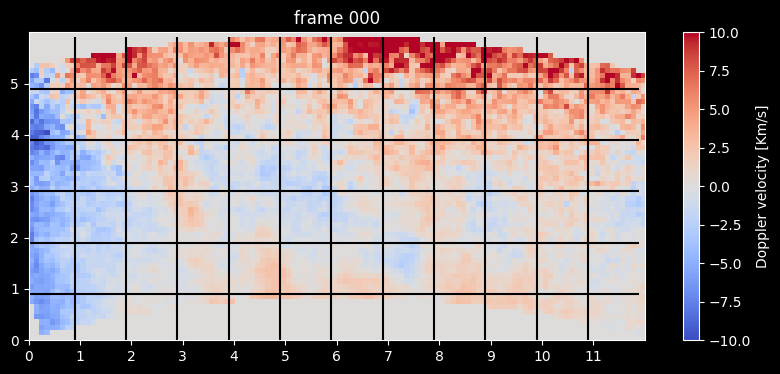

In [36]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 4), facecolor='k')
im = ax.imshow(comp_data[:, :, 0], origin='lower', cmap='coolwarm', vmin=-10, vmax=10, extent=[0, 12, 0, 6])
title = ax.set_title('frame 000')
ax.set_aspect('equal')
ax.hlines(y=(9+10*np.arange(5))/10, xmin=0, xmax=11.9, color='k')
ax.vlines(x=(9+10*np.arange(11))/10, ymin=0, ymax=5.9, color='k')
ax.set_xticks(np.arange(12))
ax.set_yticks(np.arange(6))
plt.colorbar(im, ax=ax, label='Doppler velocity [Km/s]')

def update(frame):
    im.set_data(comp_data[:, :, frame])
    title.set_text(f'frame {frame:03d}')

ani = FuncAnimation(fig=fig, func=update, frames=comp_data.shape[2], interval=100)
ani.save('./movie/comp_data_morton_block.gif', fps=10, dpi=300)

In [8]:
plt.close()
with plt.ioff():
    fig, axs = plt.subplots(nrows=6, ncols=12, figsize=(24, 12))
    axs = axs[::-1, :]
    plt.subplots_adjust(right=0.92, top=0.90, wspace=0.3, hspace=0.3)

    kx_grid, omega_grid = np.meshgrid(kx_array, omega_array, indexing='ij')
    x = kx_grid.ravel()
    y = omega_grid.ravel()
    vmin = np.min(np.log10(psd_block))
    vmax = np.max(np.log10(psd_block))
    norm = Normalize(vmin=vmin, vmax=vmax)

    cbar_ax = fig.add_axes([0.94, 0.1, 0.015, 0.8])
    cbar = None

    for k in tqdm(range(psd_block.shape[2]), total=psd_block.shape[2]):
        for i in range(6):
            for j in range(12):
                axs[i, j].clear()
                data = psd_block[i, j, k]
                z = np.log10(data).ravel()
                mesh = axs[i, j].tricontourf(x, y, z, levels=30, cmap='jet', norm=norm)
                axs[i, j].plot(np.linspace(np.min(omega_array), 0.1, 10)/0.44, np.linspace(np.min(omega_array), 0.1, 10), linestyle='--', color='k')
                axs[i, j].plot(-1*np.linspace(np.min(omega_array), 0.1, 10)/0.44, np.linspace(np.min(omega_array), 0.1, 10), linestyle='--', color='k')
                axs[i, j].set_xlim([-0.5, 0.5])
                if i==0:
                    axs[i, j].set_xlabel(f'{j}')
                if j==0:
                    axs[i, j].set_ylabel(f'{i}')

        fig.suptitle(f'Block-average PSD - frame {k:03d}', fontsize=20, fontweight='bold', y=0.98)
        if cbar is None:
            cbar = fig.colorbar(mesh, cax=cbar_ax, label=r'$log_{10}(PSD)$')
        fig.savefig(f'./fig/PSD切片/frame {k:03d}.png', dpi=150)

plt.close(fig)

  0%|          | 0/135 [00:00<?, ?it/s]

In [9]:
img.images_to_gif('./fig/PSD切片/', './movie/PSD分块.gif', fps=10)

***选取特定传播角度进行查看***

In [ ]:
lambda_r_arr = np.logspace(np.log10(2),np.log10(70), 40, base=10) * dx
lambda_r_arr = np.hstack((-lambda_r_arr, np.flip(lambda_r_arr)))
period_arr = np.logspace(np.log10(2),np.log10(90), 96, base=10) * dt

k_array = np.sort(2*np.pi/lambda_r_arr)
omega_array = np.sort(2*np.pi/period_arr)

In [ ]:
psd_45 = wavelet_direction(comp_data, k_array, omega_array, [45], dx, dy, dt, (16, 24, 1))

In [ ]:
psd_block = block_average(psd_45[..., 0], blocks=(8, 12))

In [ ]:
fig, axs = plt.subplots(nrows=8, ncols=12, figsize=(48, 32))
kx_grid, omega_grid = np.meshgrid(k_array, omega_array, indexing='ij')
x = kx_grid.ravel()
y = omega_grid.ravel()
vmin = np.min(np.log10(psd_block))
vmax = np.max(np.log10(psd_block))
with plt.ioff():
    for k in tqdm(range(psd_block.shape[2]), total=psd_block.shape[2]):
        for i in range(8):
            for j in range(12):
                axs[i, j].clear()
                data = psd_block[i, j, k]
                z = np.log10(data).ravel()
                mesh = axs[i, j].tricontourf(x, y, z, levels=30, cmap='jet', vmin=vmin, vmax=vmax)
        fig.savefig(f'./fig/PSD切片_45/frame {k:03d}.png', dpi=300)

In [ ]:
img.images_to_gif('./fig/PSD切片_45/', './movie/PSD分块_45.gif', fps=10)

In [ ]:
plt.close()

## 统计psd的演化

In [ ]:
def power_evolution(psd, k_array, omega_array, vp_interval=None):
    if vp_interval is None:
        mask = np.ones((psd.shape[3], psd.shape[4]), dtype=np.bool)
    else:
        vp = omega_array / k_array[:, np.newaxis]
        mask = (vp_interval[0] <= vp) & (vp_interval[1] >= vp)

    psd_masked = psd * mask
    int_omega = np.trapezoid(psd_masked, omega_array, axis=-1)
    total_power = np.trapezoid(int_omega, k_array, axis=-1)
    return total_power

In [ ]:
# psd_int_ky = np.trapezoid(psd_full, ky_array, axis=-2)
# power = power_evolution(psd_int_ky, kx_array, omega_array, vp_interval=(0.39, 0.49))
power = power_evolution(psd_45[..., 0], k_array, omega_array, vp_interval=(0.1, 0.5))
print(power.shape)

In [ ]:
fig, axs = plt.subplots(nrows=2, figsize=(6, 7))
log10_power = np.log10(power)
im0 = axs[0].imshow(log10_power[:, :, 0], cmap='coolwarm', origin='lower', vmin = np.min(log10_power), vmax = np.max(log10_power))
axs[0].set_aspect('equal')
axs[0].set_xlabel('x index')
axs[0].set_ylabel('r index')
text = axs[0].set_title('frame 000')
plt.colorbar(im0, ax=axs[0], label='Integrate log10(PSD), 100~500Km/s')

im1 = axs[1].imshow(comp_data[:, :, 0], cmap='coolwarm', origin='lower', vmin = -10, vmax = 10)
axs[1].set_aspect('equal')
axs[1].set_xlabel('x index')
axs[1].set_ylabel('r index')
plt.colorbar(im1, ax=axs[1], label='Doppler Velocity [Km/s]')

def update(frame):
    im0.set_data(log10_power[:, :, frame])
    im1.set_data(comp_data[:, :, frame])
    text.set_text(f'frame {frame:03d}')
    return im0, im1, text

ani = FuncAnimation(fig=fig, func=update, frames=log10_power.shape[2], interval=200)
ani.save('./movie/comp_45_psd_evolution.gif', dpi=300)

In [ ]:
plt.imshow(np.mean(power, axis=2), cmap='coolwarm', origin='lower', norm=LogNorm())

## 统计尺度演化

In [ ]:
def scale_evolution(psd, k_array, omega_array, vp_interval=None):
    if vp_interval is None:
        mask = np.ones((psd.shape[3], psd.shape[4]), dtype=np.bool)
    else:
        vp = omega_array / k_array[:, np.newaxis]
        mask = (vp_interval[0] <= vp) & (vp_interval[1] >= vp)
    psd_masked = psd * mask